<a href="https://colab.research.google.com/github/electronicvan/BT4222_FinalProject_GoodreadsRecommender/blob/main/04_SequentialLSTM_Ksplit_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. LSTM Model Base Overview
----------------

This notebook implements a Long Short-Term Memory (LSTM) based recommendation model.

**Key Aspects:**
*   **Splitting Strategy:** Utilizes a k-2, k-1, k split for training, validation, and testing.
*   **Objective:** Predict the next item in a user's recommendation sequence.
*   **Embeddings:** Incorporates `item_semantic_embedding_static` derived from book title, description, and top shelf tags.
*   **Loss Function:** Cross-Entropy Loss utilised in this baseline model.
*   **Negative Sampling:** Not included in this baseline model.

# 2. Imports

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
import torch
from torch.utils.data import Dataset
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/BT4222Project/final_updated_baseline_df.pkl'
full_df = pd.read_pickle(file_path)


Mounted at /content/drive


# 3. Metrics used in the model
- Hit Rate: Was the subsequent(target) book recommended in the top K
- MAP/NDCG: Was the subsequent(target) book ranked high in the top K

In [ ]:
def hit_rate(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    hits = [t in top for t, top in zip(targets, top_k)]
    return np.mean(hits)

def map_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ap_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ap_list.append(1.0 / rank)
        else:
            ap_list.append(0.0)
    return np.mean(ap_list)

def ndcg_at_k(preds, targets, k=10):
    top_k = np.argsort(-preds, axis=1)[:, :k]
    ndcg_list = []
    for t, top in zip(targets, top_k):
        if t in top:
            rank = np.where(top == t)[0][0] + 1
            ndcg_list.append(1.0 / np.log2(rank + 1))
        else:
            ndcg_list.append(0.0)
    return np.mean(ndcg_list)

# Aggregate performance metrics
def calculate_batch_metrics(top_k_indices, targets):
    """
    top_k_indices: numpy array of shape (batch_size, k)
    targets: numpy array of shape (batch_size,)
    Returns the sum of HR, MAP, and NDCG for the batch.
    """
    hits, map_sum, ndcg_sum = 0, 0, 0

    for t, top in zip(targets, top_k_indices):
        if t in top:
            hits += 1
            rank = np.where(top == t)[0][0] + 1
            map_sum += 1.0 / rank
            ndcg_sum += 1.0 / np.log2(rank + 1)

    return hits, map_sum, ndcg_sum

# 4. Index Representation for Embeddings

This section details the creation of numerical index representations for users and books, used for embedding layers in the model.

In [ ]:
user2idx = {u: i + 1 for i, u in enumerate(full_df['user_id'].unique())}
# Shifted +1 to reserve 0 for padding when interaction sequence was created
book2idx = {b: i + 1 for i, b in enumerate(full_df['book_id'].unique())}

full_df['user_idx'] = full_df['user_id'].map(user2idx)
full_df['book_idx'] = full_df['book_id'].map(book2idx)

num_users = len(user2idx)
num_books = len(book2idx)

# Build full user sequences in chronological order
def build_user_sequences(df):
    user_seq = defaultdict(list)

    for user, group in df.groupby('user_idx'):
        user_seq[user] = group.index.tolist()
    return user_seq

full_seq = build_user_sequences(full_df)

# 5. Data Splitting Strategy

The dataset is split into training, validation, and test sets using a time-aware approach. For each user's sequence of interactions, the following splits are applied:

*   **Training Set**: Includes all interactions up to the third-to-last item (k-2).
*   **Validation Set**: Used for predicting the second-to-last item (k-1).
*   **Test Set**: Used for predicting the last item (k).

To ensure that our data is structured to support an unbiased training of the model. These are a few considerations in which we had implemented:

To ensure that our data is structured to support an unbiased training of the model. These are a few considerations in which we had implemented:

1. **Strict Chronological Ordering of User Interactions:** Captures sequential patterns and time-dependent preferences
2. **Time-Aware Data Splitting:**
    * Training Sequence sorted by recency:
        * Includes all interactions up to the third-to-last book (k-2)
        * Includes all interactions up to the second-to-last book (k-1). Used for predicting the second-to-last item
        * Includes all interactions Used for predicting the last item (k).

The target of the validation sequence is the second-most recent interaction and the target of the testing sequence is the most recent interaction.

3. **Fixed-Length Context Window and Left Padding:** Model operates with a fixed-length context window (e.g., K=10)

   Left-padding with a reserved index (0) ensures fixed-length inputs while enabling masking of non-informative positions, all indices such as book_id and user_id are therefore 1-indexed


In [ ]:
# Split sequences into k-2, k-1, k
train_seq, val_seq, test_seq = {}, {}, {}

# Grouped the user
for user, seq in full_seq.items():
    if len(seq) < 3:
        continue

    train_seq[user] = seq[:-2]
    val_seq[user] = seq[:-1]
    test_seq[user] = seq

# 6. Sequential Dataset and DataLoader Configuration

This section outlines the creation of the `SequentialBookRecDataset` and its configuration. Key parameters include:

*   **Context Window**: Sequences are limited to a length of 10, capturing the most recent interactions for prediction.
*   **Padding Strategy**: Shorter sequences are left-padded with a dedicated padding index (0) to ensure uniform input dimensions for the model.

In [ ]:
class SequentialBookRecDataset(Dataset):
    def __init__(self, user_seq, df, seq_len = 10, split='train'):
        self.seq_len = seq_len
        self.split = split
        self.df = df
        self.user_seq = user_seq
        self.books = df['book_idx'].values
        self.static_emb = np.vstack(df['item_semantic_embedding_static'].values)

        # Build samples while eliminating data leakage in train and validation
        self.samples = []
        for user_id, indices in self.user_seq.items():
            n = len(indices)
            if n < 3: continue # Need at least 3 items for train/val/test

            if split == 'train':
                # Train on everything up to the 3rd to last item
                for pos in range(1, n - 2):
                    self.samples.append((user_id, pos))
            elif split == 'val':
                # Validate ONLY on predicting the 2nd to last item
                self.samples.append((user_id, n - 2))
            elif split == 'test':
                # Test ONLY on predicting the final item
                self.samples.append((user_id, n - 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user_id, pos = self.samples[idx]
        indices = self.user_seq[user_id]

        start = max(0, pos - self.seq_len)
        seq_idx = indices[start:pos]

        # 1. Fetch actual data
        actual_book_ids = self.books[seq_idx]
        actual_static_emb = self.static_emb[seq_idx]
        target_book_id = self.books[indices[pos]]

        # 2. Pad to seq_len
        pad_len = self.seq_len - len(seq_idx)

        if pad_len > 0:
            pad_books = np.zeros(pad_len, dtype=int) # 0 is correctly the padding index now
            pad_embs = np.zeros((pad_len, actual_static_emb.shape[1]), dtype=np.float32)

            actual_book_ids = np.concatenate([pad_books, actual_book_ids])
            actual_static_emb = np.concatenate([pad_embs, actual_static_emb])

        return {
            'seq_book_ids': torch.LongTensor(actual_book_ids),
            'seq_static_emb': torch.FloatTensor(actual_static_emb),
            'user_id': torch.LongTensor([user_id]),
            'target': torch.LongTensor([target_book_id])
        }

# 7. DataLoader Object Creation

This section initializes the `DataLoader` objects for the training, validation, and test datasets, facilitating efficient batch processing during model training and evaluation.

In [ ]:
train_dataset = SequentialBookRecDataset(train_seq, full_df)
val_dataset   = SequentialBookRecDataset(val_seq, full_df)
test_dataset  = SequentialBookRecDataset(test_seq, full_df)

train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True, num_workers = 3)
val_loader   = DataLoader(val_dataset, batch_size=2048, shuffle=False, num_workers = 3)
test_loader  = DataLoader(test_dataset, batch_size=2048, shuffle=False, num_workers = 3)

# 8. SequentialBookRecModel Definition

This section defines the architecture of the LSTM-based `SequentialBookRecModel`.

## **Key Specifications:**

 **Architecture:**
* **Input:** `book_embedding` (64-dim) concatenated with `item_semantic_embedding_static` (384-dim) → 448-dim item vector per sequence step
* **Sequential Processing:** Single-layer LSTM (hidden_dim=128), last hidden state → Dropout(0.3)
* **User Integration:** `user_embedding` (16-dim) concatenated with LSTM output
* **Output:** FFN with ReLU, LayerNorm, Dropout → Linear → `num_books + 1` logits (multi-class classification)
* **Note:** `num_books + 1` accounts for padding token; book IDs are 1-indexed

**Dropout:**
* A dropout rate of 0.3 is applied to prevent overfitting.

In [ ]:
class SequentialBookRecModel(nn.Module):
    def __init__(self,
                 num_users,
                 num_books,
                 book_emb_dim=64,
                 user_emb_dim=16,
                 lstm_hidden_dim=128,
                 lstm_layers=1,
                 seq_len=10,
                 static_emb_dim=384,
                 dropout=0.3):

        super().__init__()
        self.seq_len = seq_len

        # Embeddings: num_books + 1 to account for 0 as padding and 1..num_books as items
        self.book_emb = nn.Embedding(num_books + 1, book_emb_dim, padding_idx=0)
        self.user_emb = nn.Embedding(num_users + 1, user_emb_dim, padding_idx=0)

        # LSTM
        total_seq_emb_dim = book_emb_dim + static_emb_dim
        self.lstm = nn.LSTM(input_size = total_seq_emb_dim,
                            hidden_size = lstm_hidden_dim,
                            num_layers = lstm_layers,
                            batch_first = True)

        self.dropout = nn.Dropout(dropout)
        ffn_input_dim = lstm_hidden_dim + user_emb_dim

        # Output size num_books + 1 matches padding
        self.ffn = nn.Sequential(
            nn.Linear(ffn_input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_books + 1))

    def forward(self, seq_book_ids, seq_static_emb, user_id):
        # Sequence embeddings
        book_emb = self.book_emb(seq_book_ids)
        seq_input = torch.cat([book_emb, seq_static_emb], dim=-1)

        lstm_out, _ = self.lstm(seq_input)
        lstm_out = lstm_out[:, -1, :]
        lstm_out = self.dropout(lstm_out)

        user_id = user_id.squeeze(1)
        user_emb = self.user_emb(user_id)

        x = torch.cat([lstm_out, user_emb], dim=-1)
        logits = self.ffn(x)
        return logits

# 9. Model Initialization and Configuration

This section initialises the `SequentialBookRecModel` with specified parameters.

**Configuration:**
*   **Loss Function:**: (`CrossEntropyLoss`)
*   **Optimiser:**: (`Adam`) with weight decay for L2 Regularisaion


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = SequentialBookRecModel(
    num_users=num_users,
    num_books=num_books,
    book_emb_dim=64,
    user_emb_dim=16,
    lstm_hidden_dim=128,
    seq_len=10,
    static_emb_dim=full_df['item_semantic_embedding_static'].iloc[0].shape[0] # Obtain dimension
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

# 10. Model Training Function

This section defines the `train_model` function, which orchestrates the training and validation loops, calculates performance metrics, and plots the training progress and rank distributions.

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=10, device='cuda'):
    train_losses, val_losses = [], []
    hr_list, map_list, ndcg_list = [], [], []
    all_epoch_ranks = [] # To store distribution for every epoch

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            optimizer.zero_grad()
            logits = model(
                batch['seq_book_ids'].to(device),
                batch['seq_static_emb'].to(device),
                batch['user_id'].to(device)
            )
            targets = batch['target'].squeeze(1).to(device)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss, total_hits, total_map, total_ndcg, num_val_samples = 0, 0, 0, 0, 0
        current_epoch_ranks = []

        with torch.no_grad():
            for batch in val_loader:
                logits = model(
                    batch['seq_book_ids'].to(device),
                    batch['seq_static_emb'].to(device),
                    batch['user_id'].to(device)
                )
                targets = batch['target'].squeeze(1).to(device)
                val_loss += criterion(logits, targets).item()

                # Get top 20 to calculate hits and near-misses
                _, top_indices = torch.topk(logits, k=20, dim=1)
                targets_np = targets.cpu().numpy()
                top_indices_np = top_indices.cpu().numpy()

                batch_hits, batch_map, batch_ndcg = calculate_batch_metrics(top_indices_np[:, :10], targets_np)
                total_hits += batch_hits
                total_map += batch_map
                total_ndcg += batch_ndcg
                num_val_samples += len(targets_np)

                for i in range(len(targets_np)):
                    match = np.where(top_indices_np[i] == targets_np[i])[0]
                    if len(match) > 0:
                        current_epoch_ranks.append(match[0] + 1)
                    else:
                        current_epoch_ranks.append(21)

        all_epoch_ranks.append(current_epoch_ranks)
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        hr = total_hits / num_val_samples
        mapk = total_map / num_val_samples
        ndcg = total_ndcg / num_val_samples

        hr_list.append(hr); map_list.append(mapk); ndcg_list.append(ndcg)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | HR@10: {hr:.4f}")

    # Final Plotting logic after all epochs
    plot_final_results(train_losses, val_losses, hr_list, map_list, ndcg_list, all_epoch_ranks)

    return model, train_losses, val_losses, hr_list, map_list, ndcg_list

def plot_final_results(train_losses, val_losses, hr_list, map_list, ndcg_list, all_epoch_ranks):
    num_epochs = len(train_losses)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    epochs_range = range(1, num_epochs + 1)

    # 1. Plot Training and Validation Loss
    ax1.plot(epochs_range, train_losses, label='Train Loss', marker='o')
    ax1.plot(epochs_range, val_losses, label='Val Loss', marker='s')
    ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True)

    # 2. Plot HR, MAP, and NDCG
    ax2.plot(epochs_range, hr_list, label='HR@10', marker='o')
    ax2.plot(epochs_range, map_list, label='MAP@10', marker='s') # <-- MAP Added Here
    ax2.plot(epochs_range, ndcg_list, label='NDCG@10', marker='^')
    ax2.set_title('Performance Metrics'); ax2.legend(); ax2.grid(True)
    plt.show()

    # 3. Plot Rank Distributions for each epoch in a grid
    cols = 2
    rows = (num_epochs + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = axes.flatten()

    for i in range(num_epochs):
        ranks = all_epoch_ranks[i]
        bins = np.arange(1, 23)
        counts, _ = np.histogram(ranks, bins=bins)
        props = counts / len(ranks)

        axes[i].bar(range(1, 11), props[:10], color='green')
        axes[i].bar(range(11, 21), props[10:20], color='red')
        axes[i].bar(21, props[20], color='gray')
        axes[i].set_title(f"Epoch {i+1} Rank Distribution")
        axes[i].set_xticks(range(1, 22))
        axes[i].set_xticklabels([str(x) for x in range(1, 21)] + ["20+"])

        for j, p in enumerate(props[:10]):
            if p > 0.05: axes[i].text(j+1, p, f"{p:.2f}", ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

# 11. Initiate Model Training

This cell executes the `train_model` function to commence the training process for the `SequentialBookRecModel` for 10 epochs

Epoch 1 [Train]: 100%|██████████| 3472/3472 [03:29<00:00, 16.54it/s]


Epoch 1/10 - Train Loss: 7.6276 | Val Loss: 6.8517 | HR@10: 0.2440


Epoch 2 [Train]: 100%|██████████| 3472/3472 [03:17<00:00, 17.61it/s]


Epoch 2/10 - Train Loss: 6.9819 | Val Loss: 6.5358 | HR@10: 0.2684


Epoch 3 [Train]: 100%|██████████| 3472/3472 [03:17<00:00, 17.54it/s]


...

Epoch 8/10 - Train Loss: 6.5289 | Val Loss: 6.0804 | HR@10: 0.3086


Epoch 9 [Train]: 100%|██████████| 3472/3472 [03:22<00:00, 17.12it/s]


Epoch 9/10 - Train Loss: 6.5091 | Val Loss: 6.0542 | HR@10: 0.3106


Epoch 10 [Train]: 100%|██████████| 3472/3472 [03:23<00:00, 17.06it/s]


Epoch 10/10 - Train Loss: 6.4916 | Val Loss: 6.0286 | HR@10: 0.3135


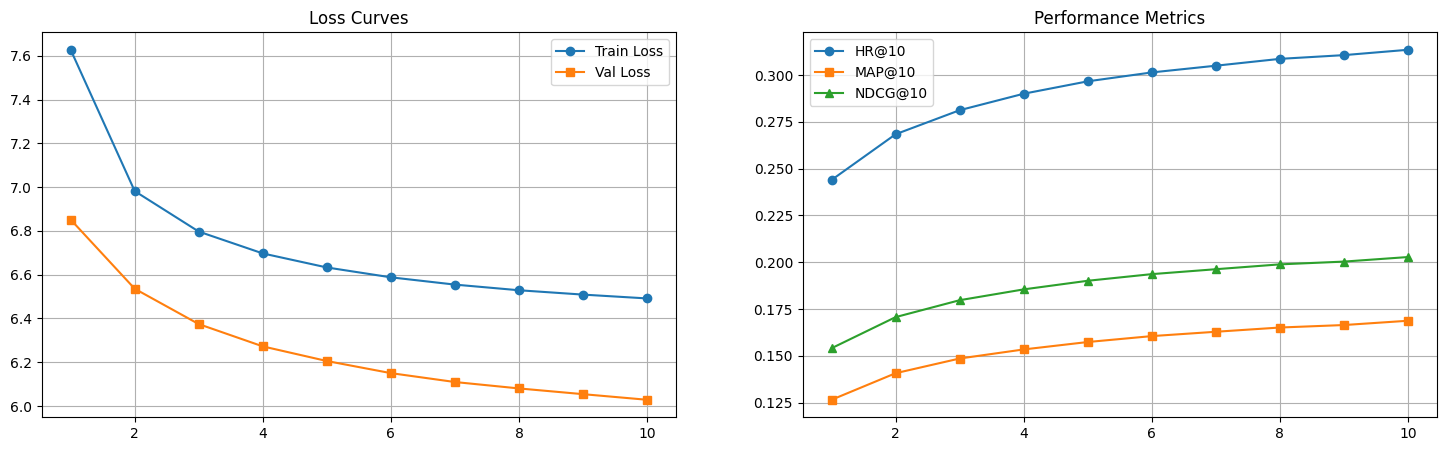

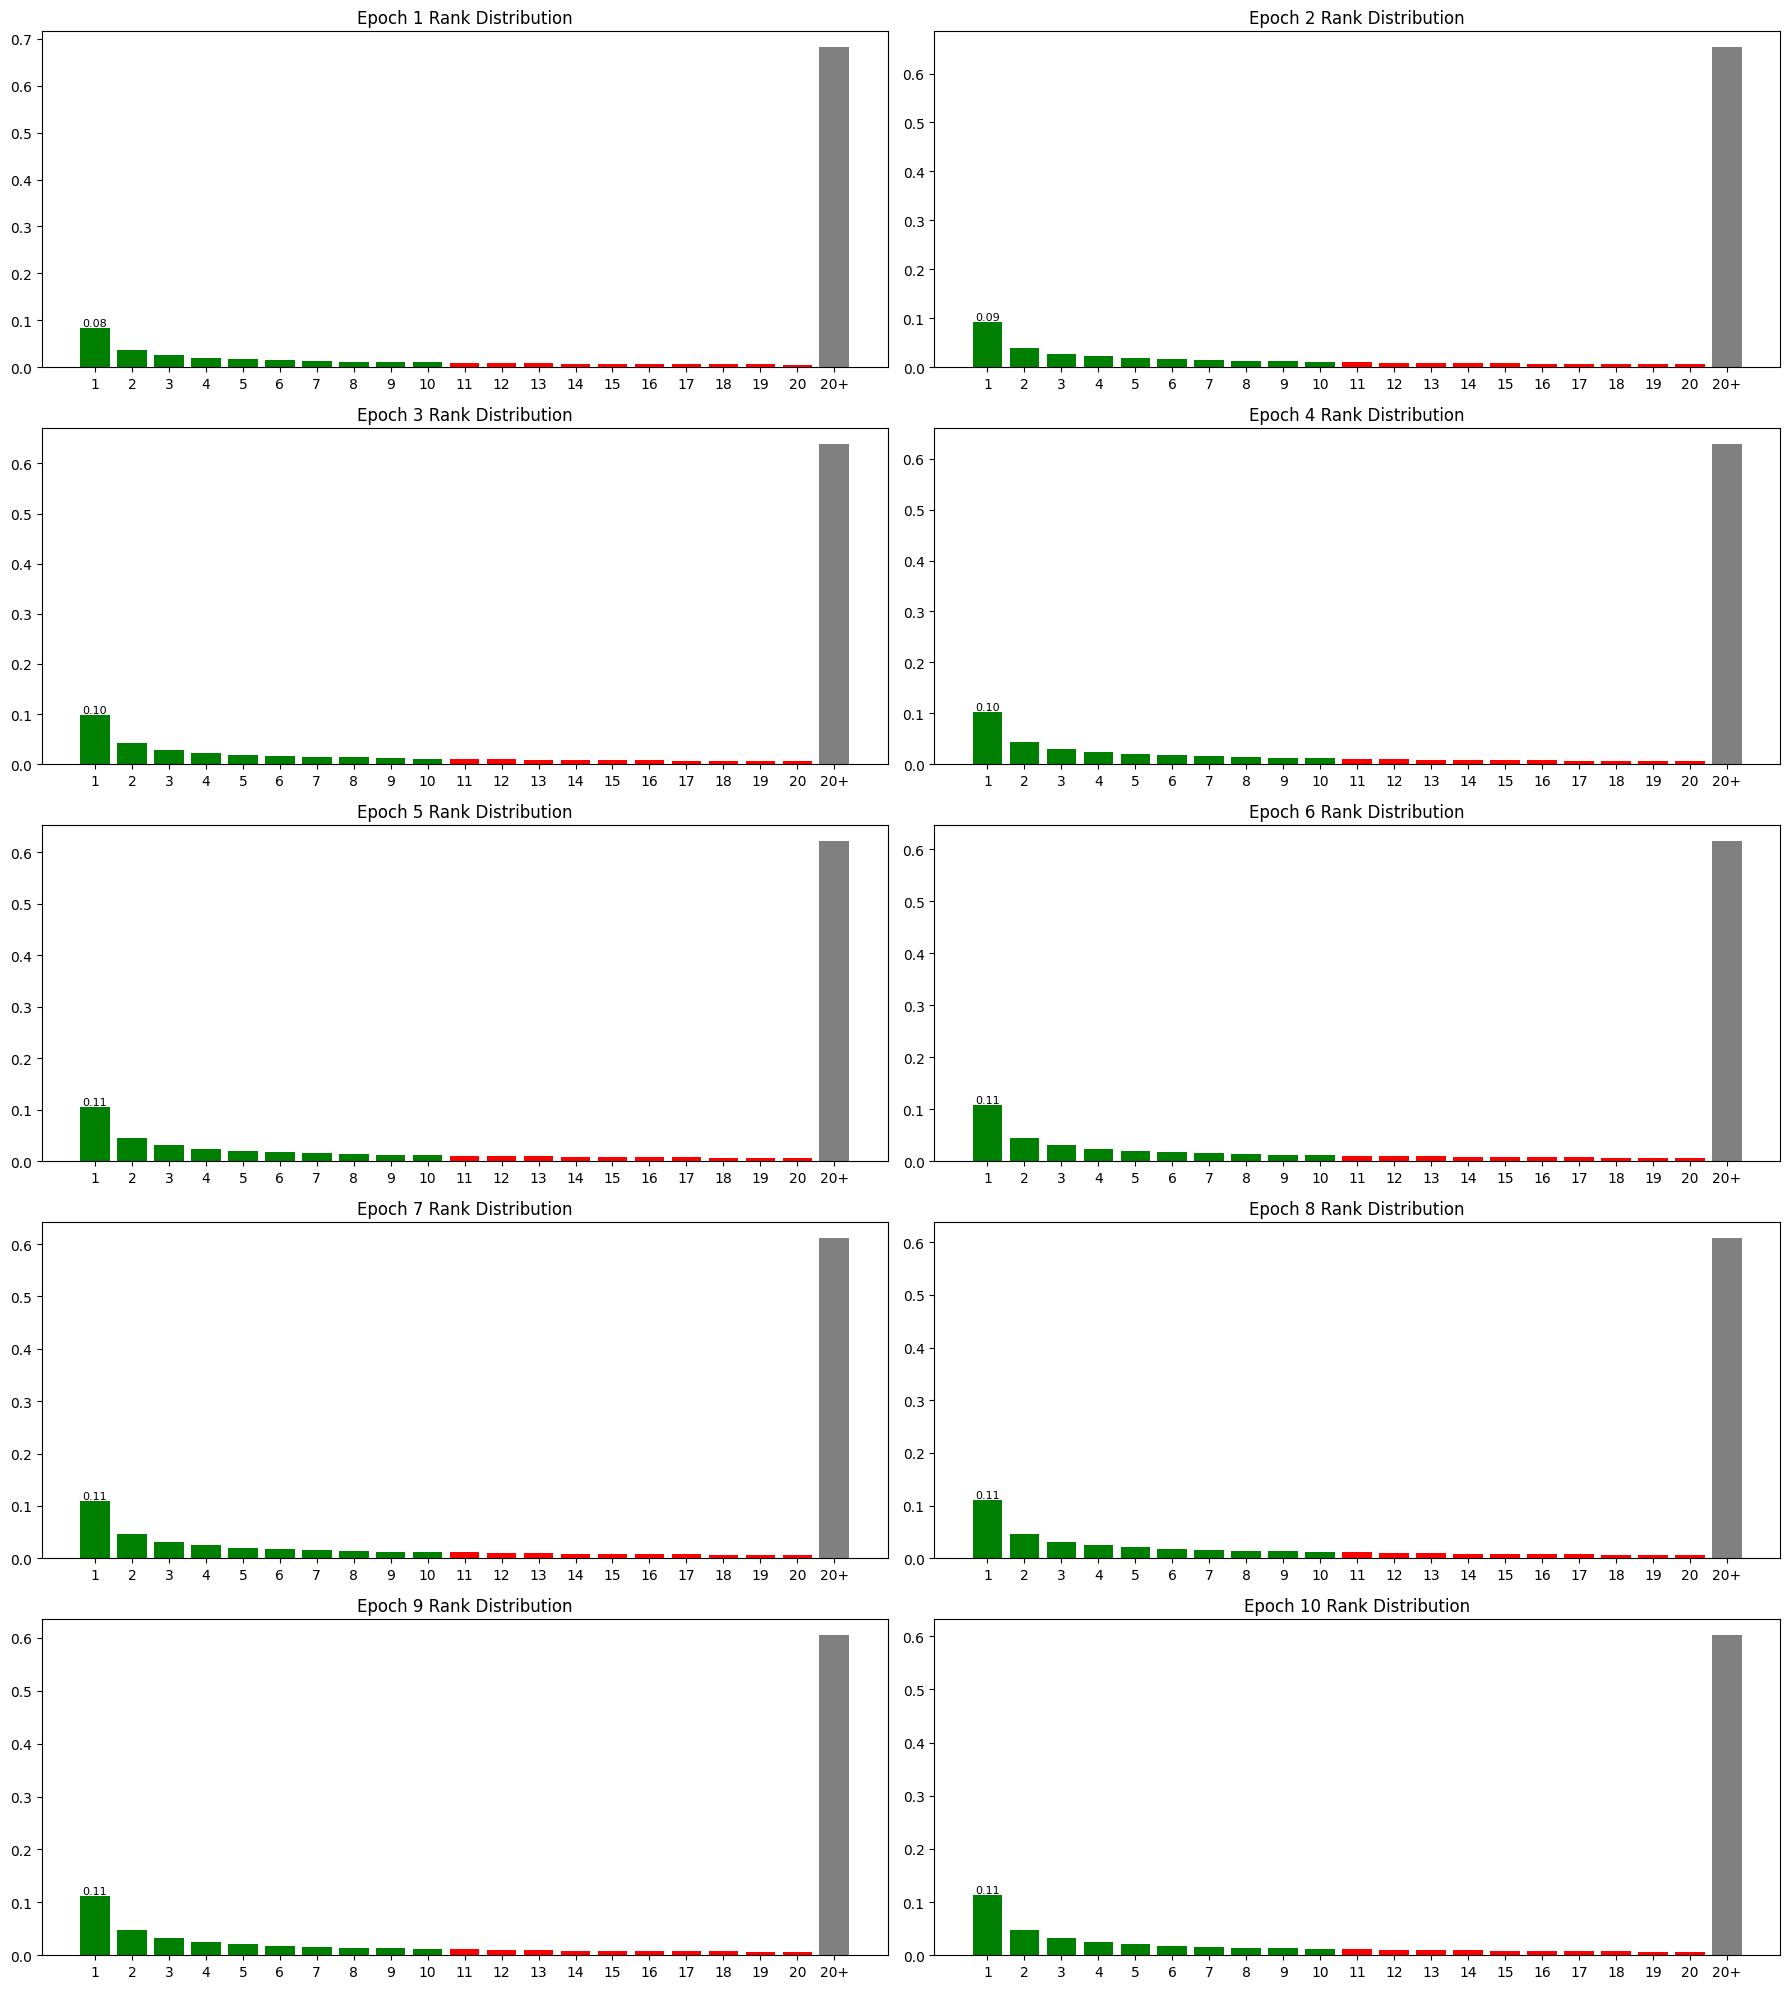

In [ ]:
trained_model = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=10,
    device=device
)

# 12. Model Evaluation on Test Set

This section defines and executes the `evaluate_test` function to assess the final performance of the trained model on the unseen test dataset using metrics such as Hit Rate, MAP, and NDCG.

In [ ]:
def evaluate_test(model, test_loader, device='cuda', k=10):
    model.eval()
    total_hits, total_map, total_ndcg = 0, 0, 0
    num_samples = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating Test Set"):
            logits = model(
                batch['seq_book_ids'].to(device),
                batch['seq_static_emb'].to(device),
                batch['user_id'].to(device)
            )
            targets = batch['target'].squeeze(1).cpu().numpy()

            # Get top k indices directly on device, then move to CPU
            _, top_indices = torch.topk(logits, k=k, dim=1)
            top_indices = top_indices.cpu().numpy()

            batch_hits, batch_map, batch_ndcg = calculate_batch_metrics(top_indices, targets)

            total_hits += batch_hits
            total_map += batch_map
            total_ndcg += batch_ndcg
            num_samples += len(targets)

    metrics = {
        f'HR@{k}': total_hits / num_samples,
        f'MAP@{k}': total_map / num_samples,
        f'NDCG@{k}': total_ndcg / num_samples
    }

    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    return metrics

# Run the evaluation:
test_results = evaluate_test(model, test_loader, device=device)

Evaluating Test Set: 100%|██████████| 3725/3725 [02:56<00:00, 21.16it/s]

HR@10: 0.3130
MAP@10: 0.1683
NDCG@10: 0.2023


# 13. Analysis of Model Performance and Cross-Entropy Loss Limitations

This section evaluates the baseline model's performance and discusses the potential theoretical limitations of using Cross-Entropy (CE) Loss for recommendation tasks.

### Observations
*   **Metric Plateau:** The performance metrics (HR@10, MAP, NDCG) show a clear stabilization, suggesting the model may have reached its representative capacity under the current configuration.
*   **Rank Distribution:** The distribution indicates that while the target item is often ranked highly (green bars), there is a significant tail of 'near-misses' where the target is ranked just outside the top positions.

Theoretically, Cross-Entropy Loss may contribute to this behavior because:
*   **Pointwise Objective:** CE treats recommendation as a multi-class classification problem. It focuses on maximising the likelihood of the ground-truth item in isolation rather than explicitly optimising the relative rank against other items.
*   **Lack of Margin:** Unlike ranking-specific losses (e.g., BPR), CE does not explicitly enforce a margin between the score of the target item and the scores of similar but incorrect items.

### Conclusion and Next Steps
To resolve these limitations, our subsequent model will implement **Bayesian Personalized Ranking (BPR)** with **negative sampling**, which is designed to optimize the relative preference between items directly.